In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [61]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [62]:
np.random.seed(42)

df = pd.DataFrame({
    'age':     np.random.randint(18, 60, 200),
    'income':  np.random.exponential(50000, 200),
    'score':   np.random.randint(40, 100, 200),
    'gender':  np.random.choice(['M', 'F'], 200),
    'city':    np.random.choice(['Lagos', 'Abuja', 'Kano'], 200),
    'bought':  np.random.choice([0, 1], 200)
})

df

,age,income,score,gender,city,bought
0,56,65137.446425,63,F,Kano,1
1,46,22926.139963,51,M,Abuja,0
2,32,50025.187387,89,F,Lagos,0
3,25,50191.891357,74,F,Abuja,1
4,38,38369.262498,99,F,Lagos,0
...,...,...,...,...,...,...
195,23,3659.121813,99,F,Lagos,1
196,49,51419.707355,88,F,Abuja,0
197,21,1343.453633,64,M,Abuja,1
198,28,44067.368890,95,M,Abuja,1


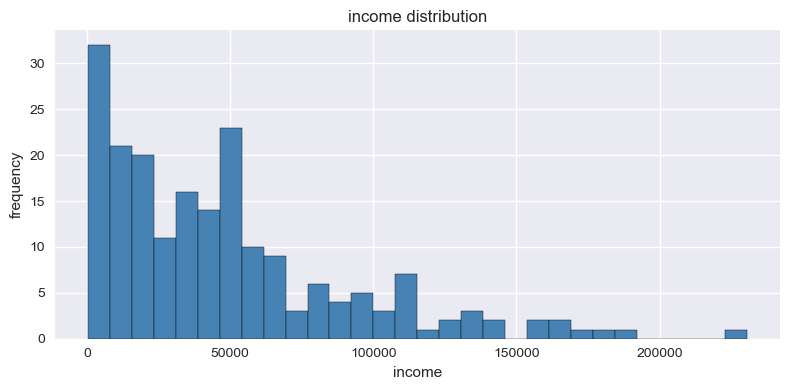

In [63]:
# 1. HISTOGRAM — distribution of a single numerical variable

plt.figure(figsize = (8, 4))
plt.hist(df['income'], bins = 30, edgecolor = 'black', color = 'steelblue')
plt.xlabel('income')
plt.ylabel('frequency')
plt.title('income distribution')
plt.tight_layout()
plt.show()

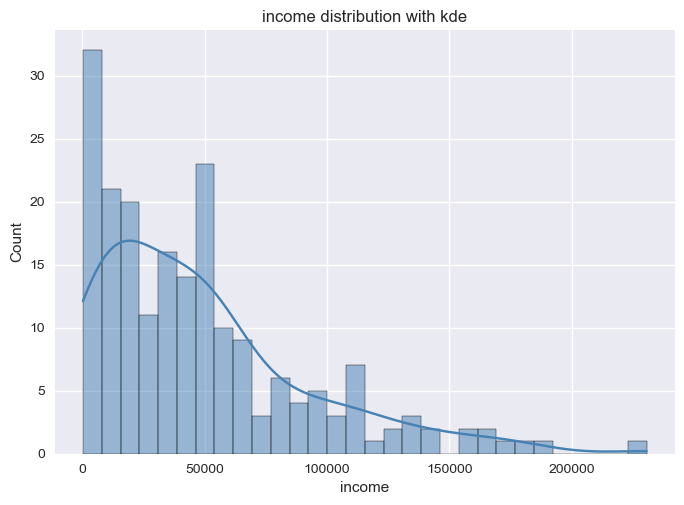

In [64]:
# Seaborn version — adds a smooth curve automatically

sns.histplot(df['income'], bins = 30,  kde = True, color = 'steelblue')
plt.title('income distribution with kde')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_2376\3321480113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'city', y = 'income', palette = 'husl')


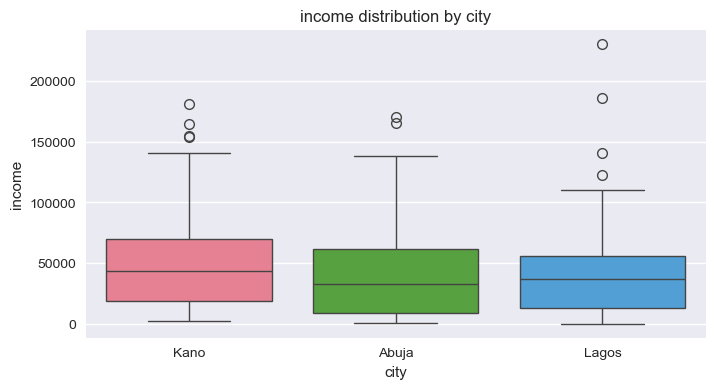

In [65]:
# More useful — compare distributions across categories

plt.figure(figsize = (8, 4))
sns.boxplot(data = df, x = 'city', y = 'income', palette = 'husl')
plt.title('income distribution by city')
plt.xlabel('city')
plt.ylabel('income')
plt.show()

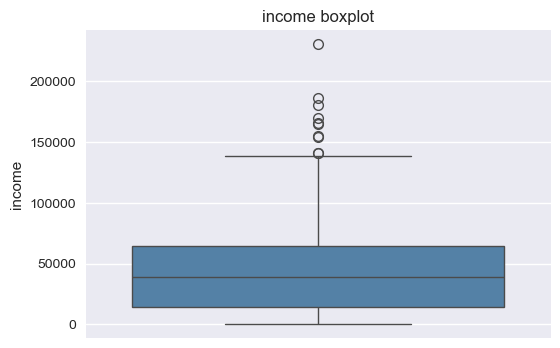

In [66]:
# Simple boxplot of one variable

plt.figure(figsize = (6, 4))
sns.boxplot(y = df['income'], color = 'steelblue')
plt.ylabel('income')
plt.title('income boxplot')
plt.show()

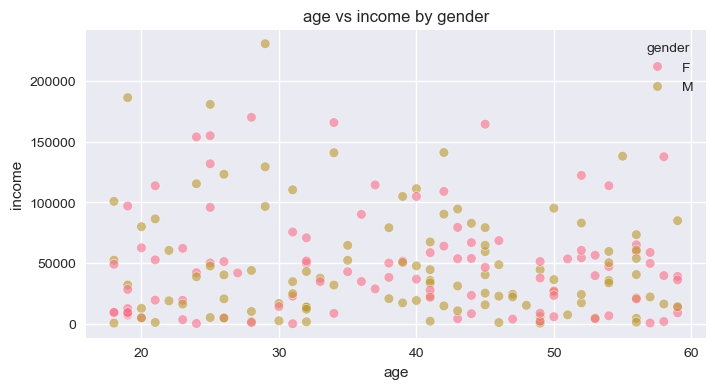

In [67]:
# scatter plot



plt.figure(figsize = (8, 4))
sns.scatterplot(data = df, x = 'age', y = 'income', hue = 'gender', alpha = 0.6)
plt.title('age vs income by gender')
plt.xlabel('age')
plt.ylabel('income')
plt.show()

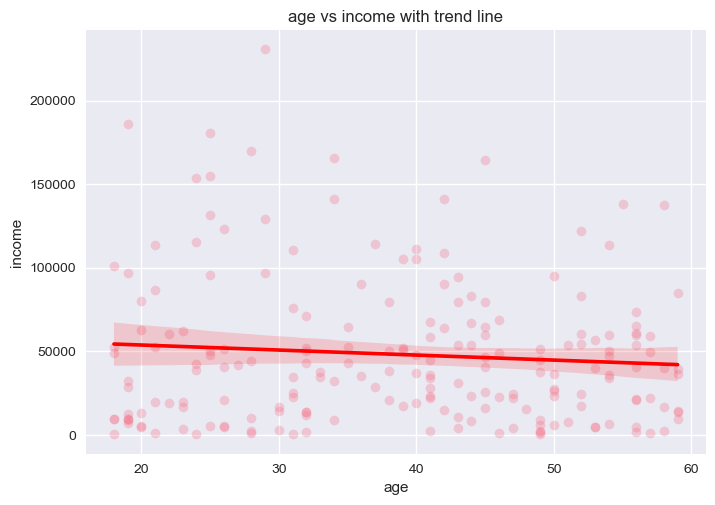

In [68]:
sns.regplot(data = df, x = 'age', y = 'income', scatter_kws = {'alpha': 0.3}, line_kws = {'color': 'red'})
plt.xlabel('age')
plt.ylabel('income')
plt.title('age vs income with trend line')
plt.show()

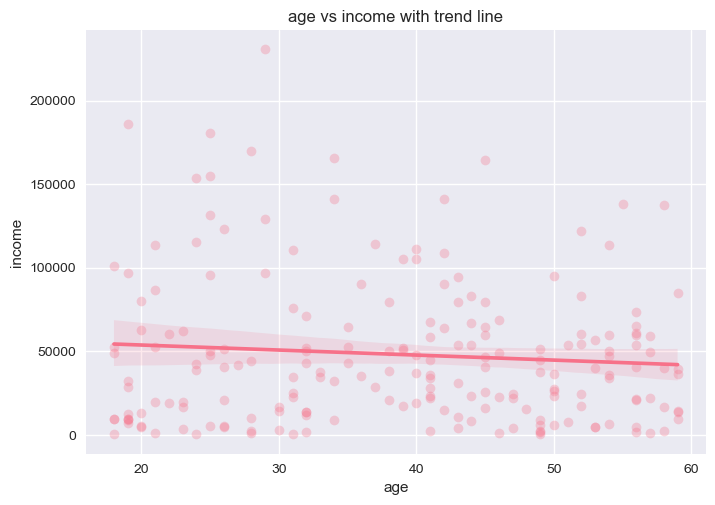

In [69]:
# Add a regression line to see the trend

sns.regplot(data = df, x = 'age', y = 'income', scatter_kws = {'alpha': 0.3})
plt.title('age vs income with trend line')
plt.show()

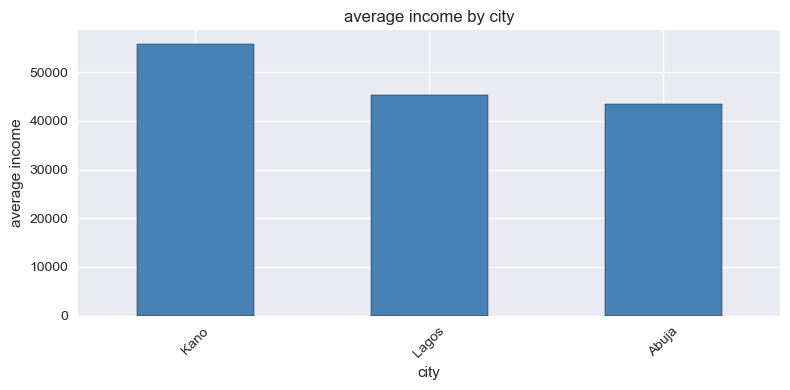

In [70]:
# Bar chart

city_avg = df.groupby('city')['income'].mean().sort_values(ascending = False)

plt.figure(figsize = (8, 4))
city_avg.plot(kind = 'bar', color = 'steelblue', edgecolor = 'black')
plt.title('average income by city')
plt.xlabel('city')
plt.ylabel('average income')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize = (8, 5))
df['churned'].value_counts().plot(kind = 'bar', color = ['steelblue', 'coral'])
plt.title('churned vs unchurned')
plt.xlabel('churned(1 = Yes, 0 = No)')
plt.ylabel('count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

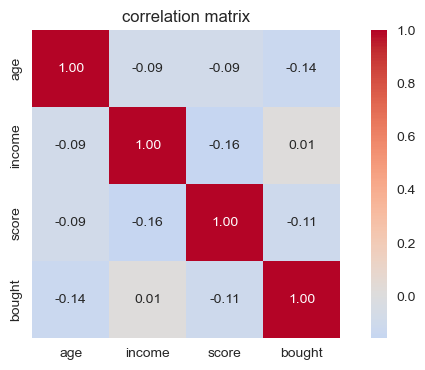

In [77]:
# Heat map

plt.figure(figsize = (8, 4))
sns.heatmap(
    df.select_dtypes('number').corr(),
    annot =True,
    fmt= '.2f',
    cmap= 'coolwarm',
    center = 0,
    square = True
)

plt.title('correlation matrix')
plt.show()

In [36]:
n = '5'
n += '5'
print(int(n) - 10)

45


FEATURE ENGINEERING 

In [78]:
a = int('20', 4)
print(a)

8


In [37]:
df = pd.DataFrame({
    'signup_date':    pd.date_range('2023-01-01', periods=200, freq='D'),
    'last_purchase':  pd.date_range('2023-06-01', periods=200, freq='D'),
    'age':            np.random.randint(18, 60, 200),
    'income':         np.random.exponential(50000, 200),
    'num_purchases':  np.random.randint(0, 50, 200),
    'total_spent':    np.random.exponential(2000, 200),
    'city':           np.random.choice(['Lagos', 'Abuja', 'Kano'], 200),
    'gender':         np.random.choice(['M', 'F'], 200),
    'bought':         np.random.choice([0, 1], 200)
})

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1
...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1


In [38]:
# extracting important date features

# sign up month

df['signup_month'] = df['signup_date'].dt.month

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1
...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7


In [39]:
# sign up day

df['signup_dayofweek'] = df['signup_date'].dt.dayofweek

# where 6 = sunday
# 0 = monday

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month,signup_dayofweek
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1,6
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1,0
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1,1
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1,2
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7,5
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7,6
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7,0
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7,1


In [40]:
# days as customer

df['days_as_customer'] = df['signup_date'] - df['last_purchase']

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month,signup_dayofweek,days_as_customer
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1,6,-151 days
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1,0,-151 days
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1,1,-151 days
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1,2,-151 days
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1,3,-151 days
...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7,5,-151 days
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7,6,-151 days
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7,0,-151 days
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7,1,-151 days


In [41]:
df['days_as_customer'] = df['last_purchase'] - df['signup_date']

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month,signup_dayofweek,days_as_customer
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1,6,151 days
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1,0,151 days
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1,1,151 days
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1,2,151 days
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1,3,151 days
...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7,5,151 days
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7,6,151 days
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7,0,151 days
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7,1,151 days


In [42]:
df['is_weekend_signup'] = df['signup_date'].dt.dayofweek >= 5

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month,signup_dayofweek,days_as_customer,is_weekend_signup
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1,6,151 days,True
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1,0,151 days,False
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1,1,151 days,False
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1,2,151 days,False
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1,3,151 days,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7,5,151 days,True
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7,6,151 days,True
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7,0,151 days,False
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7,1,151 days,False


In [43]:
df['is_weekend_signup'].value_counts()

is_weekend_signup
False    143
True      57
Name: count, dtype: int64

Mathematical transformations

In [44]:
# Log transform — fixes right-skewed distributions
# Models like linear regression assume normally distributed features

df['income_log'] = np.log1p(df['income'])

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month,signup_dayofweek,days_as_customer,is_weekend_signup,income_log
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1,6,151 days,True,10.733789
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1,0,151 days,False,10.909394
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1,1,151 days,False,9.173894
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1,2,151 days,False,11.719220
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1,3,151 days,False,10.208450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7,5,151 days,True,11.565960
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7,6,151 days,True,11.287699
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7,0,151 days,False,10.891435
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7,1,151 days,False,11.462172


In [62]:
df['total_spent_log'] = np.log1p(df['total_spent'])

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month,signup_dayofweek,days_as_customer,is_weekend_signup,income_log,total_spent_log
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1,6,151 days,True,10.733789,7.925480
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1,0,151 days,False,10.909394,5.757215
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1,1,151 days,False,9.173894,5.384202
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1,2,151 days,False,11.719220,7.434347
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1,3,151 days,False,10.208450,3.639606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7,5,151 days,True,11.565960,5.250598
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7,6,151 days,True,11.287699,6.525442
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7,0,151 days,False,10.891435,5.447030
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7,1,151 days,False,11.462172,7.651391


In [75]:
# Interaction features — combine two features into one

df['total_spent'] / (df['num_purchases'] + 1)

0       67.460806
1       24.266591
2        5.045024
3       37.603368
4        1.483073
          ...    
195      4.991587
196     16.616622
197     28.883476
198    191.142735
199    131.725662
Length: 200, dtype: float64

In [74]:
df['total_spent'] / df['num_purchases']

0       69.147326
1       26.288807
2        5.165143
3       38.457990
4        1.544868
          ...    
195      5.126495
196     17.032037
197     33.009686
198    210.257009
199    137.998313
Length: 200, dtype: float64

In [78]:
df['age_group'] = pd.cut(
    df['age'],
    bins = [0, 25, 35, 45, 100],
    labels = ['young', 'adult', 'middle', 'senior']
)

df

,signup_date,last_purchase,age,income,num_purchases,total_spent,city,gender,bought,signup_month,signup_dayofweek,days_as_customer,is_weekend_signup,income_log,total_spent_log,age_group
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,Abuja,F,1,1,6,151 days,True,10.733789,7.925480,young
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,Kano,M,0,1,0,151 days,False,10.909394,5.757215,young
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,Abuja,M,1,1,1,151 days,False,9.173894,5.384202,senior
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,Abuja,F,0,1,2,151 days,False,11.719220,7.434347,young
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,Abuja,F,1,1,3,151 days,False,10.208450,3.639606,senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,Lagos,F,1,7,5,151 days,True,11.565960,5.250598,senior
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,Kano,M,1,7,6,151 days,True,11.287699,6.525442,young
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,Abuja,M,0,7,0,151 days,False,10.891435,5.447030,middle
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,Lagos,F,1,7,1,151 days,False,11.462172,7.651391,senior


Encoding categorical variables

In [79]:
pd.get_dummies(df, columns = ['city', 'gender'], drop_first = True)

,signup_date,last_purchase,age,income,num_purchases,total_spent,bought,signup_month,signup_dayofweek,days_as_customer,is_weekend_signup,income_log,total_spent_log,age_group,city_Kano,city_Lagos,gender_M
0,2023-01-01,2023-06-01,21,45879.185925,40,2765.893056,1,1,6,151 days,True,10.733789,7.925480,young,False,False,False
1,2023-01-02,2023-06-02,22,54686.711470,12,315.465682,0,1,0,151 days,False,10.909394,5.757215,young,True,False,True
2,2023-01-03,2023-06-03,54,9641.101432,42,216.936021,1,1,1,151 days,False,9.173894,5.384202,senior,False,False,True
3,2023-01-04,2023-06-04,25,122910.478039,44,1692.151557,0,1,2,151 days,False,11.719220,7.434347,young,False,False,False
4,2023-01-05,2023-06-05,59,27130.481717,24,37.076833,1,1,3,151 days,False,10.208450,3.639606,senior,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-07-15,2023-12-13,48,105445.571772,37,189.680310,1,7,5,151 days,True,11.565960,5.250598,senior,False,True,False
196,2023-07-16,2023-12-14,23,79832.506688,40,681.281493,1,7,6,151 days,True,11.287699,6.525442,young,True,False,True
197,2023-07-17,2023-12-15,44,53713.328469,7,231.067805,0,7,0,151 days,False,10.891435,5.447030,middle,False,False,True
198,2023-07-18,2023-12-16,57,95050.285927,10,2102.570090,1,7,1,151 days,False,11.462172,7.651391,senior,False,True,False
